--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None

--- First 5 Rows ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- Missing Values ---
Custom

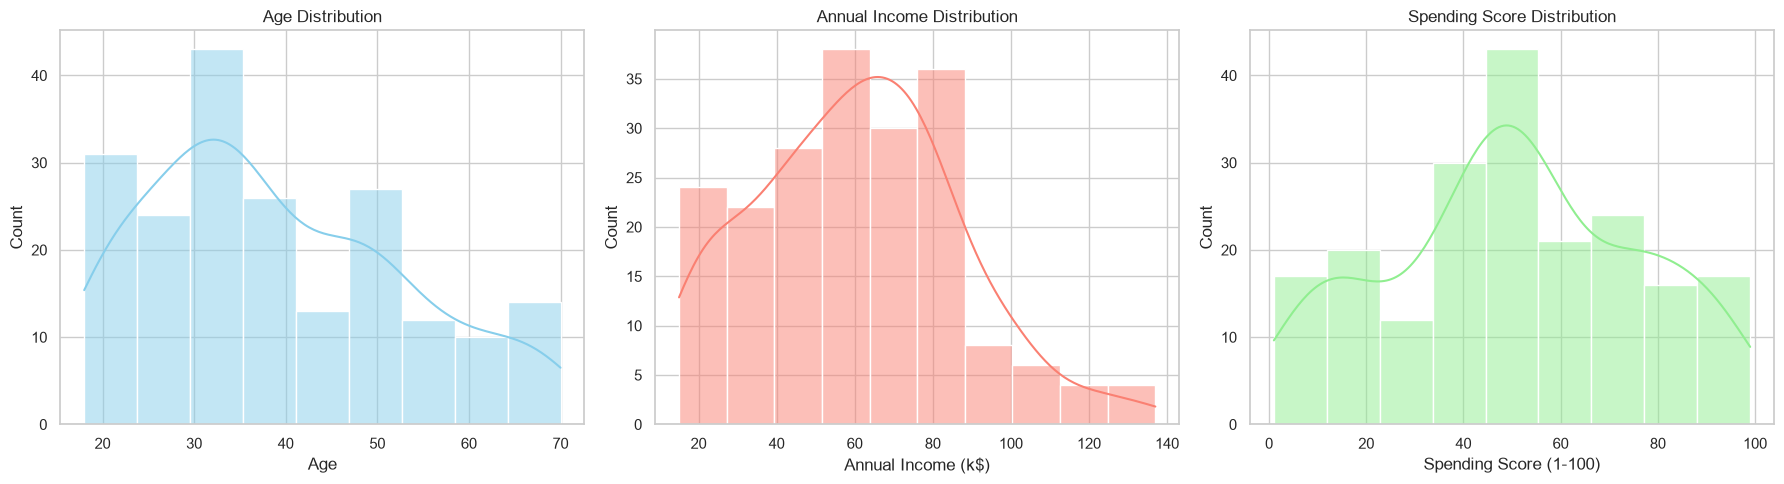

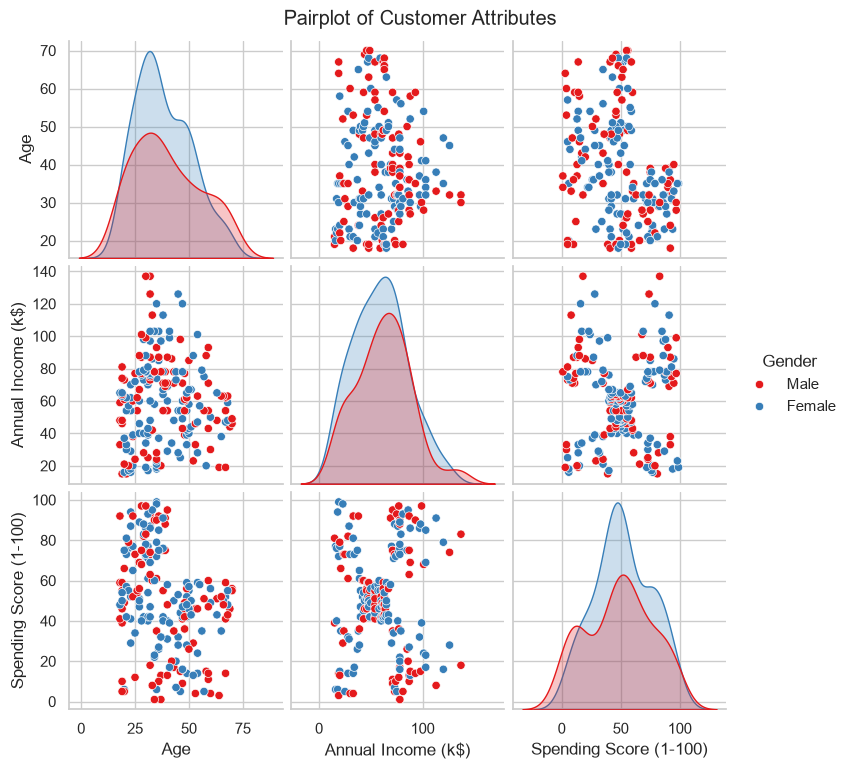

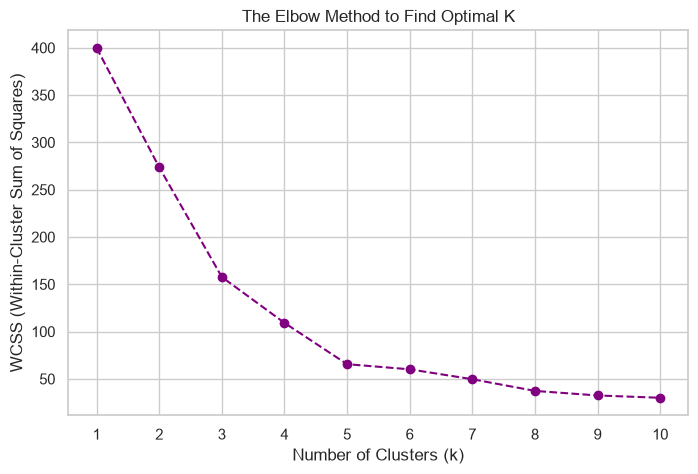

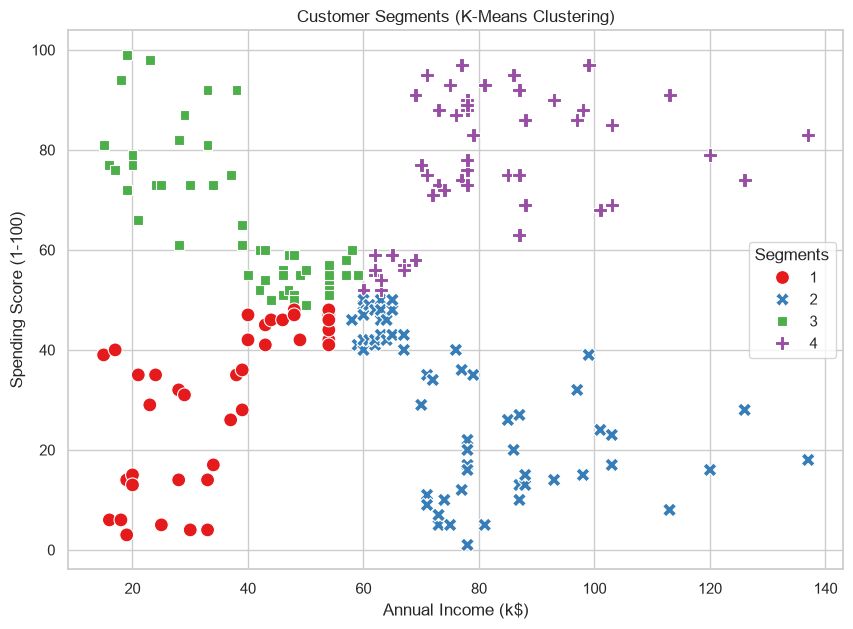


--- Profile Summary of Each Cluster ---
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
1        46.205128           35.128205               30.641026
2        40.295082           77.704918               28.590164
3        35.666667           38.960784               65.490196
4        34.510204           81.938776               76.755102


In [1]:
# ==============================================================================
# DEVELOPERSHUB CORPORATION - ADVANCED INTERNSHIP TASKS
# TASK 2: Customer Segmentation Using Unsupervised Learning
# ==============================================================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------------------
# 2. Load and Explore the Dataset
# ------------------------------------------------------------------------------
df_mall = pd.read_csv('Mall_Customers (1).csv')

print("--- Dataset Info ---")
print(df_mall.info())
print("\n--- First 5 Rows ---")
print(df_mall.head())
print("\n--- Missing Values ---")
print(df_mall.isnull().sum())

# ------------------------------------------------------------------------------
# 3. Exploratory Data Analysis (EDA)
# ------------------------------------------------------------------------------
# Distribution of numerical columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_mall['Age'], kde=True, ax=axes[0], color='skyblue').set_title('Age Distribution')
sns.histplot(df_mall['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon').set_title('Annual Income Distribution')
sns.histplot(df_mall['Spending Score (1-100)'], kde=True, ax=axes[2], color='lightgreen').set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

# Pairplot to look for visual clusters
sns.pairplot(df_mall.drop('CustomerID', axis=1), hue='Gender', palette='Set1')
plt.suptitle('Pairplot of Customer Attributes', y=1.02)
plt.show()

# ------------------------------------------------------------------------------
# 4. Data Preprocessing & Feature Selection
# ------------------------------------------------------------------------------
# Selecting features for clustering (Income and Spending Score are the classic choices)
X = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------------------------
# 5. K-Means Clustering & The Elbow Method
# ------------------------------------------------------------------------------
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='purple')
plt.title('The Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.show()

# Based on the elbow plot, the optimal number of clusters is K = 5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df_mall['Cluster'] = kmeans.fit_transform(X_scaled).argmax(axis=1) # Assign cluster labels

# ------------------------------------------------------------------------------
# 6. Dimensionality Reduction & Visualization (PCA)
# ------------------------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_mall['PCA1'] = X_pca[:, 0]
df_mall['PCA2'] = X_pca[:, 1]

# Plot clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    data=df_mall, 
    palette='Set1', 
    s=100, 
    style='Cluster'
)
plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Segments')
plt.show()

# ------------------------------------------------------------------------------
# 7. Cluster Profiles / Strategic Insights
# ------------------------------------------------------------------------------
print("\n--- Profile Summary of Each Cluster ---")
cluster_summary = df_mall.groupby('Cluster').mean(numeric_only=True)[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
print(cluster_summary)